# Isotropic–Nematic Phase Transition in Liquid Crystals

Some materials consisting of strongly anisotropic colloids or molecules behave as liquid crystals. Liquid crystals possess many of the mechanical properties of a liquid, such as high fluidity, but are similar to crystals in other physical properties. For example, they may be birefringent and may have anisotropic magnetic or electric susceptibilities.

Liquid crystals often exhibit a transition between the crystalline phase and the isotropic liquid phase as a function of the temperature or the concentration. In this exercise, we will study a temperature-induced phase transition.

Consider a two-dimensional square grid of anisotropic molecules, each characterized by a unit vector $\mathbf{u}$. The molecules $i$ and $j$ interact via the potential

$$
U(r, \mathbf{u}^{(i)}, \mathbf{u}^{(j)}) = -\varepsilon(r)\, \big(\mathbf{u}^{(i)} \cdot \mathbf{u}^{(j)}\big)^2.
$$

The function $\varepsilon(r)$ depends on the distance $r$ between the molecules. We do not consider the fluidity of the system, keeping the molecule positions fixed instead.


## 1. Monte Carlo Sampling

### (a)

Generate a $10 \times 10$ grid of unit vectors and write a script that selects a molecule and rotates its unit vector over an arbitrary angle $0 < \phi < 2\pi$.

Does this transition satisfy detailed balance?

In [17]:
import numpy as np
import matplotlib.pyplot as plt
N = 10
#create random angles
theta = 2*np.pi*np.random.rand(N,N)
#unitvectors
u_x = np.cos(theta)
u_y = np.sin(theta)



Zusätzlich Vectorfeld Ploten

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


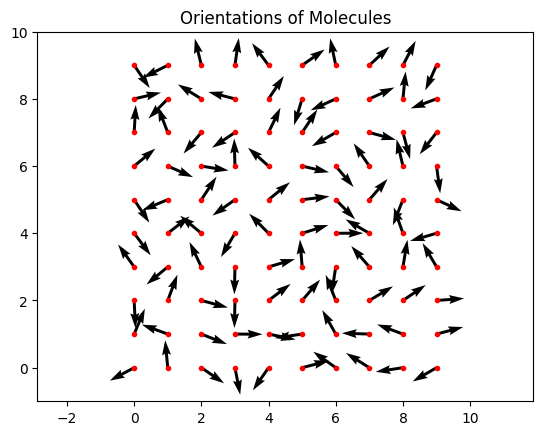

In [18]:
# Gitterpunkte
X, Y = np.meshgrid(np.arange(N), np.arange(N))

# Plot as Vectorfeld
plt.figure()
plt.quiver(X, Y, u_x, u_y)
plt.plot(X,Y,'r.')
plt.title("Orientations of Molecules")
plt.axis("equal")
plt.xlim(-1, N)
plt.ylim(-1, N)
plt.show()

Define nessesary Functions

In [19]:

#This function calculates the Potential energy between 2 Particles
#This function is not needet for the vectorized option
def E_pot_two_particles(theta1,theta2,eps=1.0):
    return -eps*np.cos(theta1-theta2)**2

#Calc whole energy of the System (loop variant)
def calc_E_tot_l(theta, eps=1.0):
    N = theta.shape[0]
    E = 0.0
    for i in range(N):
        for j in range(N):
            # right neighbour
            E += E_pot_two_particles(theta[i, j], theta[i, (j + 1) % N], eps)

            # down neighbour
            E += E_pot_two_particles(theta[i, j], theta[(i + 1) % N, j], eps)

    return E


################################################################################


#Calc whole energy of the System (vectorized variant)
def calc_E_tot_v(theta, eps=1.0):
    # to calc the interaction with every neighbor ond avoid double counting
    # use only right neigbours and neigbours below
    right = np.roll(theta,-1,axis=1)
    below = np.roll(theta,-1,axis=0)
    E = -eps*np.sum(np.cos(theta-right)**2 + np.cos(theta-below)**2)
    return E

#################################################################################

#Calc the local energy with respect to the four neigbours
def calc_E_loc(theta, i, j, eps= 1.0):
    N = theta.shape[0]
    theta_loc = theta[i,j] #vector for later calculations

    # get the neigbors -> for periodic boundary conditions use Modulo 
    neighbours = np.array([theta[(i+1)%N,j],theta[(i-1)%N,j],
                           theta[i,(j+1)%N],theta[i,(j-1)%N]])

    # summ of the 4 potential energys
    return np.sum(-eps*(np.cos(theta_loc - neighbours))**2)


### (b)

Write a Monte Carlo script that simulates a $10 \times 10$ grid of freely rotating molecules interacting only with their nearest neighbours via the potential of Eq. (1).

That means that each molecule only interacts with the four molecules on the adjacent grid points in the two perpendicular directions of the square grid. In terms of the interaction potential of Eq. (1), the function $\varepsilon(r)$ is a step function, equal to $\varepsilon$ for nearest neighbours and zero otherwise.

Use periodic boundary conditions.

In [20]:
#test feld
#Lecture Script: 1.3.9
#1st step -> choose any starting configuration
#test = np.arange(1,N**2 + 1).reshape(N,N)
#print(test)
#test2 = np.roll(test,-1,axis=0)
#print(test2)
#compar the two endergy calculation
E_vec = calc_E_tot_v(theta,1.0)
E_loop = calc_E_tot_l(theta,1.0)
print("E vectorisiert berechnet = ",E_vec)
print("E with loop berechnet = ", E_loop)

E vectorisiert berechnet =  -101.67331483262257
E with loop berechnet =  -101.67331483262252


In [21]:
# Here start with Montecarlo
N_steps = 1000
T = 0.5
for step in range(N_steps):
    i = np.random.randint(0,N)
    j = np.random.randint(0,N)
    #remember old theta
    theta_old = theta[i,j]
    #generate the new one
    theta_new = np.random.rand()*2*np.pi #is equivalent to random rotation
    #calca old local energy
    E_loc_old = calc_E_loc(theta,i,j, eps= 1.0)
    #calc new local energy 
    theta[i,j] = theta_new
    E_loc_new = calc_E_loc(theta,i,j, eps= 1.0)
    #print(E_loc_old)
    #print(E_loc_new)
    delta_E = E_loc_new - E_loc_old
    if (delta_E > 0) and (np.random.rand() > np.exp(-delta_E/T)):
        theta[i, j] = theta_old


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


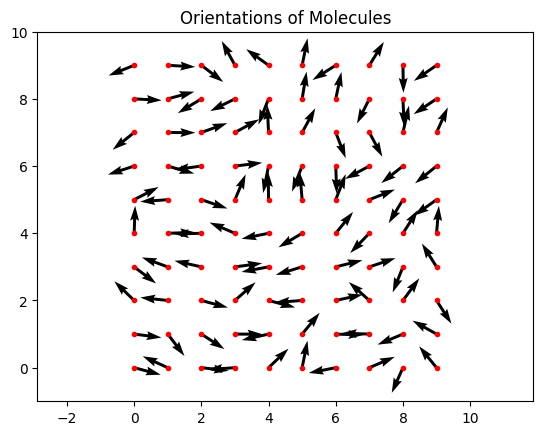

In [22]:
#test field to check the result
# Gitterpunkte
X, Y = np.meshgrid(np.arange(N), np.arange(N))
u_x = np.cos(theta)
u_y = np.sin(theta)
# Plot as Vectorfeld
plt.figure()
plt.quiver(X, Y, u_x, u_y)
plt.plot(X,Y,'r.')
plt.title("Orientations of Molecules")
plt.axis("equal")
plt.xlim(-1, N)
plt.ylim(-1, N)
plt.show()

### (c)

In order to extract meaningful results, run the Monte Carlo algorithm for a number of equilibration steps before starting the production run used for generating a sample.

After the equilibration, the system should have converged to a stable configuration. To check for convergence, calculate the interaction energy of the entire grid and plot the result as a function of Monte Carlo steps.

Determine the number of necessary equilibration steps by eye.

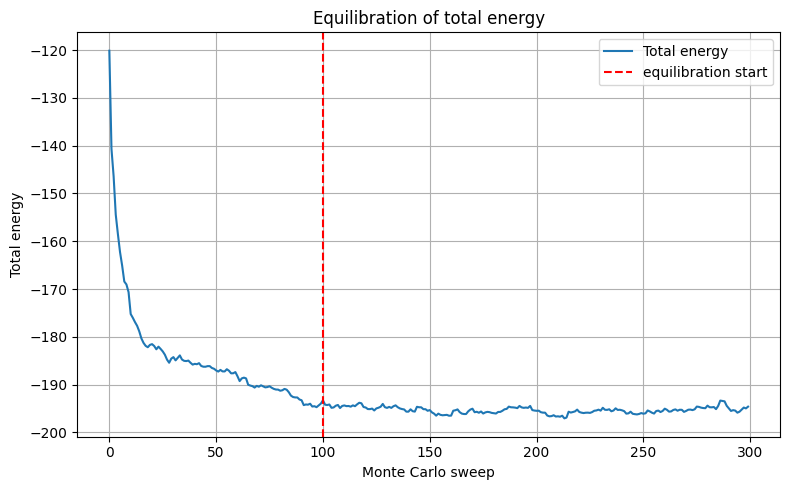

In [23]:
# Parameter
N = 10
eps = 1.0
T = 0.1
N_sweeps = 300

# new random starting angles
theta = 2 * np.pi * np.random.rand(N, N)

# Liste für die Gesamtenergie nach jedem Sweep
E_hist = np.empty(N_sweeps)

for sweep in range(N_sweeps):
    # ein Sweep = N*N einzelne MC-Versuche
    for _ in range(N * N):
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)

        # remember old theta
        theta_old = theta[i, j]

        # generate the new one
        theta_new = np.random.uniform(0.0, 2.0 * np.pi)

        # calc old local energy
        E_loc_old = calc_E_loc(theta, i, j, eps=eps)

        # calc new local energy
        theta[i, j] = theta_new
        E_loc_new = calc_E_loc(theta, i, j, eps=eps)

        delta_E = E_loc_new - E_loc_old

        # Metropolis criterion
        if delta_E > 0 and np.random.rand() > np.exp(-delta_E / T):
            theta[i, j] = theta_old

    # Gesamtenergie nach jedem Sweep speichern
    E_hist[sweep] = calc_E_tot_l(theta, eps=eps)

# gewählter Equilibrium-Beginn, z. B. aus dem Plot abgelesen
eq_sweep = 100

plt.figure(figsize=(8, 5))
plt.plot(E_hist, lw=1.5, label="Total energy")
plt.axvline(eq_sweep, linestyle="--",color="red" ,lw=1.5,
            label=f"equilibration start")

plt.xlabel("Monte Carlo sweep")
plt.ylabel("Total energy")
plt.title("Equilibration of total energy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 2. Order parameter

The elements of the two-dimensional nematic order tensor are defined as

$
Q_{\alpha\beta} = \frac{1}{N} \sum_{i=1}^{N} \left( 2 u_{\alpha}^{(i)} u_{\beta}^{(i)} - \delta_{\alpha\beta} \right),
$

where $N$ is the number of molecules, $u_{\alpha}^{(i)}\) and (\u_{\beta}^{(i)}\$ are the components of the orientation vector of molecule \(i\), and \(\delta_{\alpha\beta}\) is the Kronecker delta.

The largest eigenvalue of this tensor corresponds to the nematic order parameter \(S\), which can also be written as

$
S = \frac{1}{N} \sum_{i=1}^{N} \left( 2\cos^2\psi_i - 1 \right),
$

where \(\psi_i\) is the angle between the orientation of molecule \(i\) and the generally unknown nematic director.

From this expression, it follows that \(S \to 1\) when all molecules are perfectly aligned with the director. In contrast, \(S \to 0\) in the isotropic phase, where the molecular orientations are randomly distributed.

## (a)

Write a script to calculate the tensor $Q$ and the order parameter $S$ at every Monte Carlo step from Eq. (2).  
Calculate the distribution of the order parameter $S$ over a large number of Monte Carlo steps.  
Plot the corresponding histogram both for a temperature $k_B T \ll \varepsilon$ and for a temperature $k_B T \gg \varepsilon$.  
Add error bars to the plots according to the Bayesian approach with a flat prior.

In [24]:
# determine Q and S
def determine_Q_S(theta):
    N = theta.size
    # x and y component of U 
    u_x = np.cos(theta)
    u_y = np.sin(theta)

    # calc Q_ij as given in formula 2 
    Q_xx  = np.sum(2*u_x*u_x - 1) / N
    Q_yy  = np.sum(2*u_y*u_y - 1) / N
    # Q_xy = Q_yx
    Q_xy = np.sum(2*u_x*u_y) / N

    # Built the matrix
    Q = np.matrix([[Q_xx,Q_xy],
                  [Q_xy,Q_yy]])
    
    #calc eigenvalues of Q 
    ev = np.linalg.eigvals(Q)
    #get the largest eingenvale for S 
    S = np.max(ev)

    return Q,S

#Q_test, S_test = determine_Q_S(theta)
#print("Q =")
#print(Q_test)
#print("S =", S_test)

Last Q:
[[-0.93624849 -0.24224584]
 [-0.24224584  0.93624849]]
Last S: 0.967080288074543


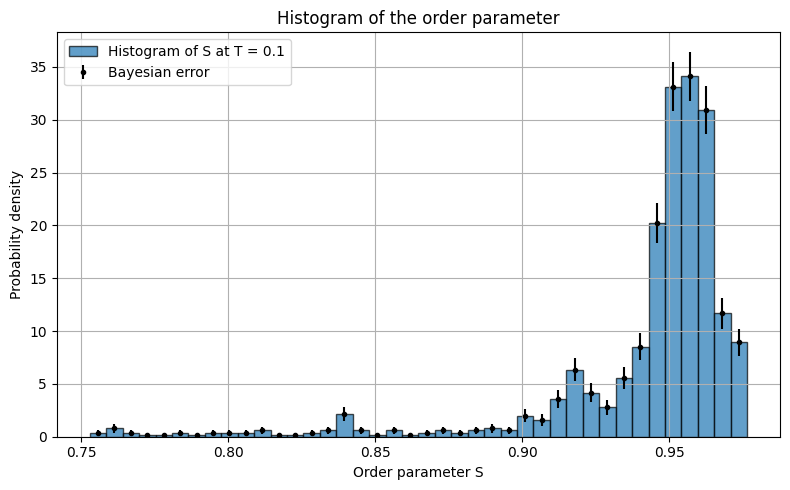

Last Q:
[[ 0.07116925 -0.12284249]
 [-0.12284249 -0.07116925]]
Last S: 0.14196950633905364


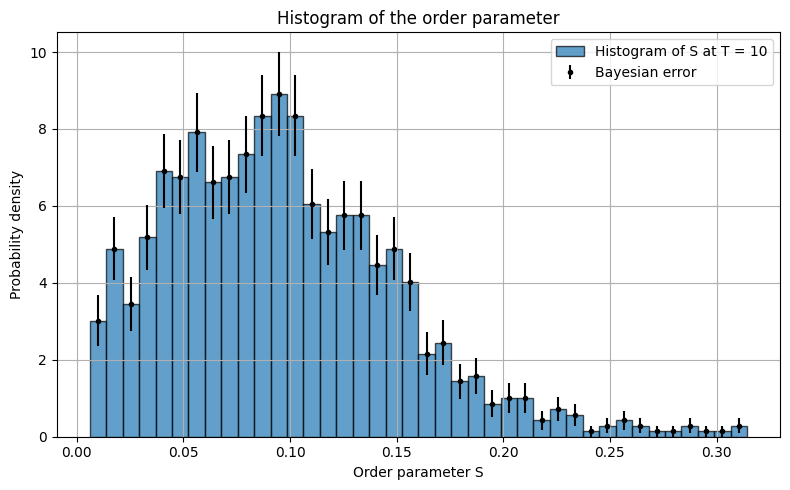

In [25]:
# Parameter
N = 10
eps = 1.0
T = [0.1,10]
N_sweeps_to_eq = 100
N_sweeps = 900
np.random.seed(42)

for temps in range(len(T)):
    # new random starting angles
    theta = 2 * np.pi * np.random.rand(N, N)

    # optional: Energieverlauf zur Kontrolle
    E_hist = np.empty(N_sweeps_to_eq + N_sweeps)

    # Liste für den Order-Parameter im Produktionslauf
    S_hist = np.empty(N_sweeps)

    # ---------------------------------
    # Monte Carlo simulation with sweeps
    # ---------------------------------
    for sweep in range(N_sweeps_to_eq + N_sweeps):

        # ein Sweep = N*N einzelne MC-Versuche
        for _ in range(N * N):
            i = np.random.randint(0, N)
            j = np.random.randint(0, N)

            # remember old theta
            theta_old = theta[i, j]

            # generate new angle
            theta_new = np.random.rand() * 2 * np.pi

            # old local energy
            E_loc_old = calc_E_loc(theta, i, j, eps=eps)

            # try new angle
            theta[i, j] = theta_new
            E_loc_new = calc_E_loc(theta, i, j, eps=eps)

            delta_E = E_loc_new - E_loc_old

            # Metropolis criterion
            if delta_E > 0 and np.random.rand() > np.exp(-delta_E / T[temps]):
                theta[i, j] = theta_old

        # Energie nach jedem Sweep speichern
        E_hist[sweep] = calc_E_tot_l(theta, eps=eps)

        # erst nach der Äquilibrierung S sammeln
        if sweep >= N_sweeps_to_eq:
            Q, S = determine_Q_S(theta)
            S_hist[sweep - N_sweeps_to_eq] = S

    # letzte Werte ausgeben
    print("Last Q:")
    print(Q)
    print("Last S:", S)

    # ---------------------------------
    # plot S during production run
    # ---------------------------------
    #plt.figure(figsize=(8, 5))
    #plt.plot(np.arange(N_sweeps_to_eq, N_sweeps_to_eq + N_sweeps), S_hist)
    #plt.xlabel("Monte Carlo sweep")
    #plt.ylabel("Order parameter S")
    #plt.title("Order parameter during production run")
    #plt.grid(True)
    #plt.tight_layout()
    #plt.show()

    # ---------------------------------
    # histogram of S
    # ---------------------------------
    N_bins = 40
    counts, edges = np.histogram(S_hist, bins=N_bins, density=False)

    bin_width = edges[1] - edges[0]
    centers = 0.5 * (edges[:-1] + edges[1:])

    numberOfSamples = len(S_hist)

    # Bayesian expectation value and error for pdf with flat prior
    expectationValue = (counts + 1) / ((numberOfSamples + 2) * bin_width)
    error = np.sqrt((counts + 1) * (numberOfSamples - counts + 1) /
                    ((numberOfSamples + 2)**2 * (numberOfSamples + 3))) / bin_width

    plt.figure(figsize=(8, 5))
    plt.bar(centers, expectationValue, width=bin_width, alpha=0.7, edgecolor="black",
            label=f"Histogram of S at T = {T[temps]}")
    plt.errorbar(centers, expectationValue, yerr=error, fmt="o", markersize=3,
                color="black", label="Bayesian error")

    plt.xlabel("Order parameter S")
    plt.ylabel("Probability density")
    plt.title("Histogram of the order parameter")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

T = 0.1
tau_int = 43.0846


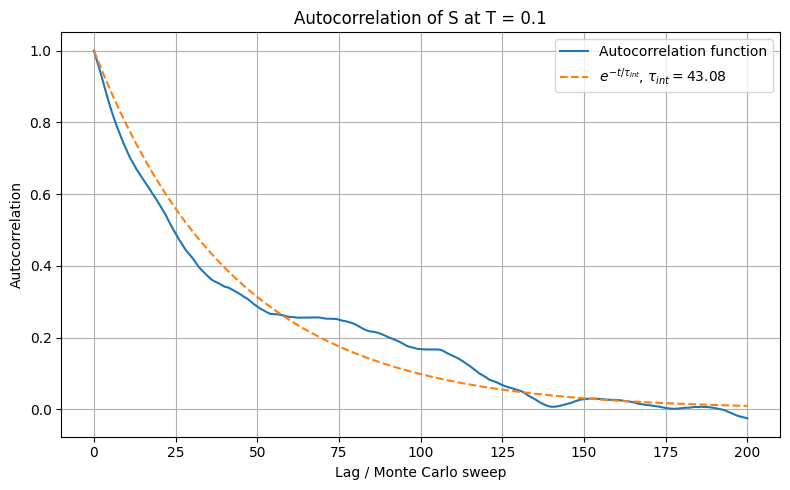

T = 10.0
tau_int = 0.7284


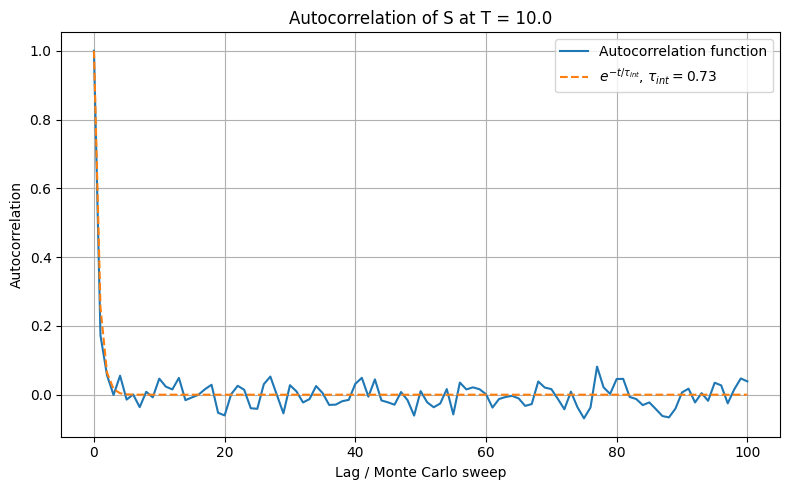

In [26]:
# =================================
# 2b) Autocorrelation of S
# =================================

def autocorrelation_lag_1(S, lag):
    N_samples = len(S)

    previousValues = S[:N_samples - lag]
    followingValues = S[lag:]

    meanAll = np.mean(S)

    numerator = np.sum((previousValues - meanAll) * (followingValues - meanAll))
    denominator = np.sum((S - meanAll)**2)

    return numerator / denominator


# ---------------------------------
# alternative empirical definition
# commented out on purpose
# ---------------------------------
def autocorrelation_lag(S, lag):
    N_samples = len(S)

    previousValues = S[:N_samples - lag]
    followingValues = S[lag:]

    meanPrevVals = np.mean(previousValues)
    meanFollVals = np.mean(followingValues)

    numerator = np.sum((previousValues - meanPrevVals) * (followingValues - meanFollVals))
    denominator = np.sqrt(np.sum((previousValues - meanPrevVals)**2) *
                          np.sum((followingValues - meanFollVals)**2))

    return numerator / denominator


def autocorrelation_function(S, maxLag=None):
    N_samples = len(S)

    if maxLag is None:
        maxLag = N_samples - 1

    acf = np.empty(maxLag + 1)

    for lag in range(maxLag + 1):
        acf[lag] = autocorrelation_lag_1(S, lag)

    return acf


def integrated_autocorrelation_time(acf):
    tau_int = 0.5

    for lag in range(1, len(acf)):
        if acf[lag] < 0:
            break
        tau_int += acf[lag]

    return tau_int


def plot_autocorrelation(acf, tau_int, temperature):
    lags = np.arange(len(acf))
    exp_decay = np.exp(-lags / tau_int)

    plt.figure(figsize=(8, 5))
    plt.plot(lags, acf, lw=1.5, label="Autocorrelation function")
    plt.plot(lags, exp_decay, "--", lw=1.5,
             label=rf"$e^{{-t/\tau_{{int}}}}$, $\tau_{{int}} = {tau_int:.2f}$")

    plt.xlabel("Lag / Monte Carlo sweep")
    plt.ylabel("Autocorrelation")
    plt.title(f"Autocorrelation of S at T = {temperature}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ---------------------------------
# generate new S series for 2b
# ---------------------------------
T = [0.1, 10.0]
N_sweeps_to_eq = 100
N_sweeps = 900
np.random.seed(42)

for temps in range(len(T)):
    theta = 2 * np.pi * np.random.rand(N, N)

    S_hist = np.empty(N_sweeps)

    for sweep in range(N_sweeps_to_eq + N_sweeps):
        for _ in range(N * N):
            i = np.random.randint(0, N)
            j = np.random.randint(0, N)

            theta_old = theta[i, j]
            theta_new = np.random.rand() * 2 * np.pi

            E_loc_old = calc_E_loc(theta, i, j, eps=eps)

            theta[i, j] = theta_new
            E_loc_new = calc_E_loc(theta, i, j, eps=eps)

            delta_E = E_loc_new - E_loc_old

            if delta_E > 0 and np.random.rand() > np.exp(-delta_E / T[temps]):
                theta[i, j] = theta_old

        if sweep >= N_sweeps_to_eq:
            Q, S = determine_Q_S(theta)
            S_hist[sweep - N_sweeps_to_eq] = S

    # choose max lag
    if T[temps] == 0.1:
        maxLag = 200
    else:
        maxLag = 100

    acf = autocorrelation_function(S_hist, maxLag=maxLag)
    tau_int = integrated_autocorrelation_time(acf)

    print(f"T = {T[temps]}")
    print(f"tau_int = {tau_int:.4f}")

    plot_autocorrelation(acf, tau_int, T[temps])

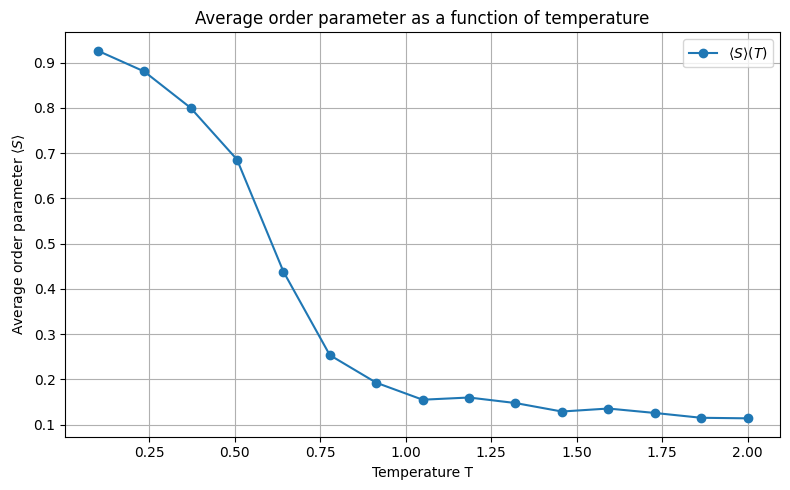

In [27]:
# =================================
# 3a) Average order parameter <S>(T)
# =================================

# Parameter
N = 10
eps = 1.0
N_sweeps_to_eq = 100
N_sweeps = 300
np.random.seed(42)

# temperatures
T_values = np.linspace(0.1, 2.0, 15)

# arrays for results
S_mean_values = np.empty(len(T_values))

for t_idx in range(len(T_values)):
    T = T_values[t_idx]

    # new random starting angles
    theta = 2 * np.pi * np.random.rand(N, N)

    # list for S values after equilibration
    S_hist = np.empty(N_sweeps)

    # Monte Carlo simulation
    for sweep in range(N_sweeps_to_eq + N_sweeps):

        for _ in range(N * N):
            i = np.random.randint(0, N)
            j = np.random.randint(0, N)

            theta_old = theta[i, j]
            theta_new = np.random.rand() * 2 * np.pi

            E_loc_old = calc_E_loc(theta, i, j, eps=eps)

            theta[i, j] = theta_new
            E_loc_new = calc_E_loc(theta, i, j, eps=eps)

            delta_E = E_loc_new - E_loc_old

            if delta_E > 0 and np.random.rand() > np.exp(-delta_E / T):
                theta[i, j] = theta_old

        if sweep >= N_sweeps_to_eq:
            Q, S = determine_Q_S(theta)
            S_hist[sweep - N_sweeps_to_eq] = S

    # average order parameter
    S_mean_values[t_idx] = np.mean(S_hist)

# plot
plt.figure(figsize=(8, 5))
plt.plot(T_values, S_mean_values, "o-", label=r"$\langle S \rangle (T)$")
plt.xlabel("Temperature T")
plt.ylabel(r"Average order parameter $\langle S \rangle$")
plt.title(r"Average order parameter as a function of temperature")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

T = 0.100, <S> = 0.9265, std = 0.0417, tau_int = 32.8727, N_eff = 4.56
T = 0.236, <S> = 0.8807, std = 0.0334, tau_int = 30.7580, N_eff = 4.88
T = 0.371, <S> = 0.8003, std = 0.0461, tau_int = 9.4798, N_eff = 15.82
T = 0.507, <S> = 0.6860, std = 0.0682, tau_int = 8.3340, N_eff = 18.00
T = 0.643, <S> = 0.4384, std = 0.1452, tau_int = 18.3962, N_eff = 8.15
T = 0.779, <S> = 0.2537, std = 0.1214, tau_int = 6.1344, N_eff = 24.45
T = 0.914, <S> = 0.1927, std = 0.0939, tau_int = 3.9439, N_eff = 38.03
T = 1.050, <S> = 0.1551, std = 0.0750, tau_int = 1.7220, N_eff = 87.11
T = 1.186, <S> = 0.1600, std = 0.0905, tau_int = 2.9418, N_eff = 50.99
T = 1.321, <S> = 0.1478, std = 0.0767, tau_int = 1.9394, N_eff = 77.34
T = 1.457, <S> = 0.1290, std = 0.0604, tau_int = 1.2666, N_eff = 118.43
T = 1.593, <S> = 0.1356, std = 0.0686, tau_int = 1.4627, N_eff = 102.55
T = 1.729, <S> = 0.1259, std = 0.0658, tau_int = 1.5931, N_eff = 94.15
T = 1.864, <S> = 0.1152, std = 0.0593, tau_int = 1.0036, N_eff = 149.46
T =

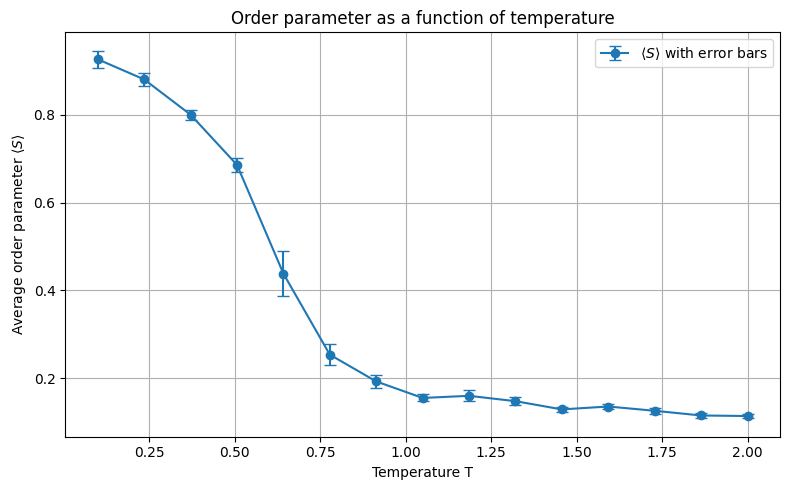

In [28]:
# =================================
# 3b) <S>(T) with error bars
# =================================

# Parameter
N = 10
eps = 1.0
N_sweeps_to_eq = 100
N_sweeps = 300
np.random.seed(42)

# temperatures
T_values = np.linspace(0.1, 2.0, 15)

# arrays for results
S_mean_values = np.empty(len(T_values))
S_std_values = np.empty(len(T_values))
S_error_values = np.empty(len(T_values))
tau_int_values = np.empty(len(T_values))

for t_idx in range(len(T_values)):
    T = T_values[t_idx]

    # new random starting angles
    theta = 2 * np.pi * np.random.rand(N, N)

    # list for S values after equilibration
    S_hist = np.empty(N_sweeps)

    # Monte Carlo simulation
    for sweep in range(N_sweeps_to_eq + N_sweeps):

        for _ in range(N * N):
            i = np.random.randint(0, N)
            j = np.random.randint(0, N)

            theta_old = theta[i, j]
            theta_new = np.random.rand() * 2 * np.pi

            E_loc_old = calc_E_loc(theta, i, j, eps=eps)

            theta[i, j] = theta_new
            E_loc_new = calc_E_loc(theta, i, j, eps=eps)

            delta_E = E_loc_new - E_loc_old

            if delta_E > 0 and np.random.rand() > np.exp(-delta_E / T):
                theta[i, j] = theta_old

        if sweep >= N_sweeps_to_eq:
            Q, S = determine_Q_S(theta)
            S_hist[sweep - N_sweeps_to_eq] = S

    # mean S
    S_mean = np.mean(S_hist)

    # autocorrelation and tau_int
    acf = autocorrelation_function(S_hist, maxLag=min(200, len(S_hist)-1))
    tau_int = integrated_autocorrelation_time(acf)

    # standard deviation of S
    S_std = np.std(S_hist, ddof=1)

    # effective number of independent samples
    N_eff = len(S_hist) / (2.0 * tau_int)

    # error of the mean
    S_error = S_std / np.sqrt(N_eff)

    # store values
    S_mean_values[t_idx] = S_mean
    S_std_values[t_idx] = S_std
    S_error_values[t_idx] = S_error
    tau_int_values[t_idx] = tau_int

    print(f"T = {T:.3f}, <S> = {S_mean:.4f}, std = {S_std:.4f}, tau_int = {tau_int:.4f}, N_eff = {N_eff:.2f}")

# plot
plt.figure(figsize=(8, 5))
plt.errorbar(T_values, S_mean_values, yerr=S_error_values, fmt="o-", capsize=4,
             label=r"$\langle S \rangle$ with error bars")
plt.xlabel("Temperature T")
plt.ylabel(r"Average order parameter $\langle S \rangle$")
plt.title(r"Order parameter as a function of temperature")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Estimated transition temperature: T_c ≈ 0.643
Maximum standard deviation: sigma_S ≈ 0.1452


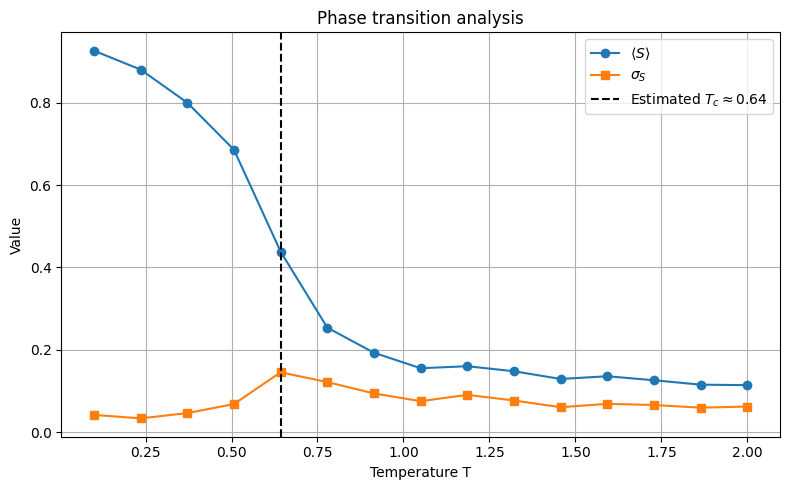

In [29]:
# =================================
# 3c) Estimate transition temperature
# =================================

# transition temperature estimate from maximum standard deviation
idx_max_std = np.argmax(S_std_values)
T_transition = T_values[idx_max_std]

print(f"Estimated transition temperature: T_c ≈ {T_transition:.3f}")
print(f"Maximum standard deviation: sigma_S ≈ {S_std_values[idx_max_std]:.4f}")

# plot mean S and standard deviation
plt.figure(figsize=(8, 5))
plt.plot(T_values, S_mean_values, "o-", label=r"$\langle S \rangle$")
plt.plot(T_values, S_std_values, "s-", label=r"$\sigma_S$")
plt.axvline(T_transition, linestyle="--", color="black",
            label=rf"Estimated $T_c \approx {T_transition:.2f}$")

plt.xlabel("Temperature T")
plt.ylabel("Value")
plt.title("Phase transition analysis")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()